# Moana v2: getting your model inputs from Datamesh

This notebook introduces **Datamesh**, Oceanum's data platform, and **`oceanum-python`**, the Python client used to talk to it. It walks through the data a New Zealand regional ocean forecast needs, using one concrete scenario:

> **A 7-day forecast with data assimilation, starting at `T0`.**
> - **Assimilation window, `T0 − 3 days` → `T0`:** observations to assimilate. These are satellite SST (NOAA ACSPO L3S-LEO), Argo profiles and Mangōpare sensors, with OSTIA as a gap-free reference.
> - **Forecast horizon, `T0` → `T0 + 7 days`:** forcing. The ocean initial and boundary conditions come from Copernicus Marine GLO12, the atmosphere from ECMWF IFS, and the tides from TPXO9.

Each section queries one dataset, shows what comes back and plots it. The code is meant to be copied into your own workflows.

**Contents**
1. Setup and connection
2. Datamesh in five ideas
3. The scenario: dates, domain, and the dateline
4. Observations for the assimilation window
5. Ocean initial and boundary conditions
6. Atmospheric forcing
7. Tides
8. Summary, gaps and tips

Running the whole notebook takes roughly 10–15 minutes. Most of that is the first fetch of 3-D ocean fields from Copernicus. Re-running should be much faster because Datamesh caches what it has fetched.

## 1. Setup and connection

You need Python ≥ 3.10 and:

```sh
pip install oceanum matplotlib
```

`oceanum` brings in `xarray`, `pandas` and `geopandas`.

**Your token.** Datamesh authenticates with a personal API token. The client reads it from the `DATAMESH_TOKEN` environment variable. Keep the token out of notebooks and scripts: set it in your shell (`export DATAMESH_TOKEN=...`) or in a `.env` file that is never committed.

In [4]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from oceanum.datamesh import Connector

warnings.filterwarnings("ignore", message="No data found for query")
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

datamesh = Connector()   # reads DATAMESH_TOKEN; Connector(token="...") also works
print("Connected to", datamesh.host)

You are using version 1.2.0 of oceanum_python. A new version is available: 1.2.1. Please update your client to benefit from the latest features and updates.
Connected to datamesh.oceanum.io


## 2. Datamesh in five ideas

1. **A datasource is a named dataset.** It has an id (e.g. `metoffice-glo-sst-l4-nrt-obs-sst-v2`) and metadata: a name, a description, its variables, a spatial footprint (`geom`) and a time range (`tstart`, `tend`). **`tend = None` means the datasource is live:** it keeps growing as new data is published.
2. **Datamesh fetches data on demand.** Many datasources are not copies. Datamesh reads them from the provider when you ask: Copernicus Marine, NASA PO.DAAC, ECMWF's open-data bucket, ERDDAP servers. You always get the provider's latest data, in the same form.
3. **Everything looks like is an xarray dataset.** Except for data what fits the geodataframe model all data comes back as an `xarray.Dataset`. Gridded data comes back as a `xarray.Dataset`. So does tabular data (Argo, sensors), with a single `index` dimension; `.to_dataframe()` turns it into pandas. Each datasource maps its own coordinate names onto the standard roles `t`, `x`, `y`, `z` (see `coordinates` below). That is how one query language works for all of them.
4. **Subset on the server with a query.** `datamesh.query(...)` takes a datasource id plus filters, and only the subset travels to you:
   - `variables`;
   - `timefilter`: a range or a list of times;
   - `geofilter`: a bounding box or a GeoJSON feature;
   - `levelfilter`: vertical levels;
   - `parameters`: datasource-specific options, such as a forecast cycle.

   This query language is called **OceanQL**.
5. **Nothing is downloaded until you ask.** `datamesh.load_datasource(id)` opens a whole datasource lazily: you get the full structure at no cost, and `xarray` fetches only the data chunks required to compute the values you are after. Very large datasources are refused ("Request too large"). For those, `datamesh.query(..., use_dask=True)` gives you a lazy *subset* instead.

### The catalogue

`get_catalog()` lists the datasources your account can read. It accepts free-text `search`, plus `timefilter`/`geofilter` to keep only datasources that cover a place and period.

In [15]:
catalog = datamesh.get_catalog()
table = pd.DataFrame([{"id": d.id, "name": d.name,
                       "tstart": str(d.tstart)[:10], "tend": str(d.tend)[:10] if d.tend else "live"}
                      for d in catalog]).sort_values("id")
with pd.option_context("display.max_colwidth", 80, "display.max_rows", 100):
    display(table.set_index("id"))

,name,tstart,tend
id,,,
argo_floats,Argo Float Measurements,1997-07-28,live
cmems_mod_glo_phy-so_anfc_0-083deg_pt6h-i,CMEMS 6-hourly instantaneous salinity from Global Ocean Physics Analysis and...,2022-06-01,live
cmems_mod_glo_phy-thetao_anfc_0-083deg_pt6h-i,CMEMS 6-hourly instantaneous sea water temperature from Global Ocean Physics...,2022-06-01,live
cmems_mod_glo_phy_anfc_0-083deg_pt1h-m,CMEMS Hourly mean fields from Global Ocean Physics Analysis and Forecast,2022-06-01,live
cmems_mod_glo_phy_anfc_0-083deg_static-static-arco,CMEMS Mean dynamic topography from Global Ocean Physics Analysis and Forecast,1970-01-01,live
cmems_mod_glo_phy_my_0-083deg_static-static-arco,CMEMS Mean dynamic topography from Global Ocean Physics Reanalysis,1970-01-01,live
ecmwf_cape_0p25,ECMWF IFS convective potential energy forecast,2024-10-03,2024-10-04
ecmwf_ifs_0p25_oper_sfc,ECMWF 0.25° 3/6-hourly IFS Global deterministic forecast single-level fields,2024-11-12,live
ecmwf_ifs_0p25_oper_sfc_2024,ECMWF 0.25° 3/6-hourly IFS Global deterministic forecast single-level fields...,2024-03-18,2024-11-22


In [16]:
# Free-text search ranks datasources by relevance (searching names, descriptions and tags)
for d in list(datamesh.get_catalog(search="sea surface temperature"))[:6]:
    print(f"{d.id:50s} {d.name}")

noaa-acspo-l3s-leo-am-day-nrt                      NOAA ACSPO L3S-LEO AM day-time SST, global 0.02°, near real time
cmems_mod_glo_phy_my_0-083deg_static-static-arco   CMEMS Mean dynamic topography from Global Ocean Physics Reanalysis
cmems_mod_glo_phy_anfc_0-083deg_static-static-arco CMEMS Mean dynamic topography from Global Ocean Physics Analysis and Forecast
argo_floats                                        Argo Float Measurements
metoffice-glo-sst-l4-nrt-obs-sst-v2                CMEMS Level 4 Daily Global Ocean sea surface temperature and sea ice analysis from OSTIA near-real-time observation
esacci-glo-sst-l4-rep-obs-sst                      CMEMS Level 4 Daily Global Ocean sea and ice surface temperature from ESA SST CCI observation reprocessing


### One datasource's metadata

`get_datasource(id)` returns the metadata only. `coordinates` maps the standard roles to this datasource's own names.

In [11]:
meta = datamesh.get_datasource("noaa-acspo-l3s-leo-pm-night-podaac")
print("name       :", meta.name)
print("time range :", meta.tstart, "->", meta.tend or "live")
print("coordinates:", meta.coordinates)
print("footprint  :", meta.geom.bounds)
print("variables  :")
for name, var in meta.variables.items():
    attrs = var.get("attrs", {})
    print(f"   {name:25s} {str(var.get('dims')):25s} {attrs.get('units', '')}")
print()
print(meta.description)

name       : NOAA ACSPO L3S-LEO PM night-time SST, global 0.02°, from 2002 (PO.DAAC)
time range : 2002-07-04 12:00:00+00:00 -> live
coordinates: {'t': 'time', 'x': 'lon', 'y': 'lat'}
footprint  : (-180.0, -90.0, 180.0, 90.0)
variables  :
   crs                       []                        
   l2p_flags                 ['time', 'lat', 'lon']    
   sses_bias                 ['time', 'lat', 'lon']    kelvin
   sst_dtime                 ['time', 'lat', 'lon']    
   quality_level             ['time', 'lat', 'lon']    
   sea_surface_temperature   ['time', 'lat', 'lon']    kelvin
   sses_standard_deviation   ['time', 'lat', 'lon']    kelvin

NOAA STAR ACSPO (v2.81) L3S super-collated sea surface skin temperature from low-Earth-orbit satellites on the PM orbit (~01:30/13:30 local overpass), night-time files only, on a global 0.02° grid, one field per day (stamped 12:00 UTC), from 2002-07-04 to the present. GHRSST GDS2: sea_surface_temperature in kelvin with SSES bias and standard deviati

### Opening a datasource lazily

This is the **entire** latest ECMWF forecast: 33 global fields at every time step. Opening it takes a few seconds, because only the structure is transferred. This can be useful for datasource introspection but is not the recommended way to work with data as this approach can involve much larger (hence slower) data downloads than the later describe query interface would.

In [12]:
ecmwf_all = datamesh.load_datasource("ecmwf_ifs_0p25_oper_sfc")
print(f"{ecmwf_all.nbytes / 1e9:.0f} GB if fully loaded; nothing transferred yet")
ecmwf_all

7 GB if fully loaded; nothing transferred yet


<xarray.Dataset> Size: 7GB
Dimensions:    (time: 49, latitude: 721, longitude: 1440)
Coordinates:
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 392B 2026-10-07T18:00:00 ... 2026-10-13T...
Data variables: (12/33)
    asn        (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    d2m        (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    ewss       (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    lsm        (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    msl        (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    mucape     (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    ...         ...
    ttr        (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    u10        (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    u100       (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    v10        (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    v100       (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
    zos        (time, latitude, longitude) float32 203MB dask.array<chunksize=(49, 361, 480), meta=np.ndarray>
Attributes:
    title:                    ECMWF IFS open-data forecast, 0.25 deg, single-...
    institution:              European Centre for Medium-Range Weather Foreca...
    source:                   ECMWF open data (gs://ecmwf-open-data), ifs/0p2...
    license:                  CC-BY-4.0
    forecast_reference_time:  2026-10-07T18:00:00Z
    Conventions:              CF-1.7
    _coordinates:             {"t":"time","x":"longitude","y":"latitude"}
    _datamesh_cache_hash:     54063a1f743f2501acb37217865ac4d3df10a5337e0cf00...

Selecting and computing fetches only what is needed. Here that is one field at one point, for the whole forecast:

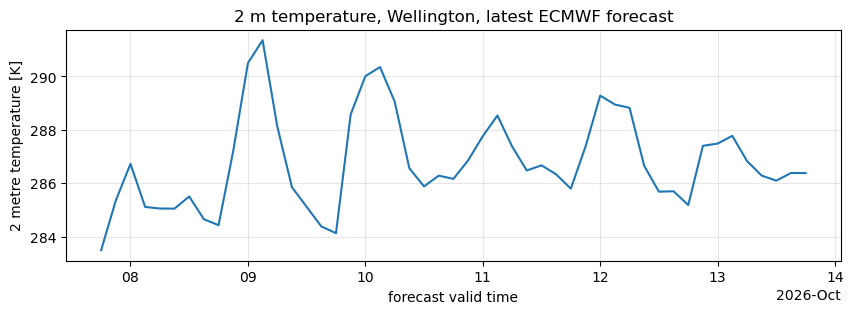

In [13]:
ecmwf_all.t2m.sel(longitude=174.8, latitude=-41.3, method="nearest").plot(figsize=(10, 3))
plt.title("2 m temperature, Wellington, latest ECMWF forecast"); plt.show()

The whole ACSPO archive (0.02°, global, daily since 2002) is too big to open in one piece. Restrict it to New Zealand with a lazy query instead. That gives every day since 2002 for a 17° × 18° box, still without transferring any pixels:

In [14]:
acspo_nz = datamesh.query(datasource="noaa-acspo-l3s-leo-pm-night-podaac", use_dask=True,
                          geofilter={"type": "bbox", "geom": [163, -50, 180, -32]})
print(f"{acspo_nz.sizes['time']} days, {acspo_nz.nbytes / 1e9:.0f} GB if fully loaded")
acspo_nz.sea_surface_temperature

/home/sebastien/project/P_datamesh/datamesh-gateway-v1/oceanum-python/src/oceanum/datamesh/connection.py:336: UserWarning: Query is too large for direct access, using lazy access with dask
  warnings.warn(


8861 days, 258 GB if fully loaded


<xarray.DataArray 'sea_surface_temperature' (time: 8861, lat: 900, lon: 850)> Size: 54GB
dask.array<open_dataset-sea_surface_temperature, shape=(8861, 900, 850), dtype=float64, chunksize=(1, 900, 850), chunktype=numpy.ndarray>
Coordinates:
    crs      int32 4B ...
  * lat      (lat) float32 4kB -32.01 -32.03 -32.05 ... -49.95 -49.97 -49.99
  * lon      (lon) float32 3kB 163.0 163.0 163.1 163.1 ... 179.9 180.0 180.0
  * time     (time) datetime64[s] 71kB 2002-07-04T12:00:00 ... 2026-10-06T12:...
Attributes:
    comment:                SST obtained by regression with buoy measurements...
    long_name:              sea surface sub-skin temperature
    source:                 NOAA
    units:                  kelvin
    valid_max:              32767
    valid_min:              -200
    standard_name:          sea_surface_subskin_temperature
    coverage_content_type:  physicalMeasurement

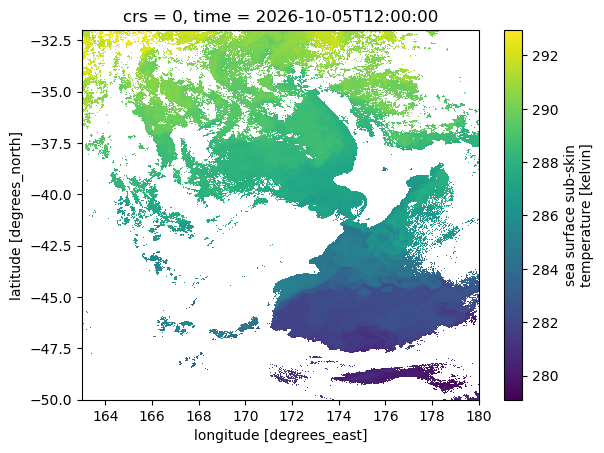

In [19]:
acspo_nz.sea_surface_temperature.isel(time=-2).plot()

## 3. The scenario: dates, domain, and the dateline

**Dates.** `T0` is the most recent 00:00 or 12:00 UTC that is at least 12 hours old. ECMWF has finished publishing that forecast cycle by then, so the forcing and the forecast start together. Replace it with any date you like to rerun a past case (a hindcast). Note that the ECMWF datasource only goes back to November 2024.

In [22]:
T0 = (pd.Timestamp.now("UTC").tz_localize(None) - pd.Timedelta("12h")).floor("12h")
# T0 = pd.Timestamp("2026-09-20T00:00")     # e.g. a fixed hindcast date

ASSIM_WINDOW = [T0 - pd.Timedelta("3D"), T0]
FORECAST = [T0, T0 + pd.Timedelta("7D")]

def timerange(window):
    """An OceanQL timefilter selecting everything between two times."""
    return {"type": "range", "times": [str(t) for t in window]}

print("T0                 :", T0)
print("assimilation window:", ASSIM_WINDOW[0], "->", ASSIM_WINDOW[1])
print("forecast horizon   :", FORECAST[0], "->", FORECAST[1])

T0                 : 2026-10-07 12:00:00
assimilation window: 2026-10-04 12:00:00 -> 2026-10-07 12:00:00
forecast horizon   : 2026-10-07 12:00:00 -> 2026-10-14 12:00:00


**Domain.** The domain is a box around New Zealand: 163°E–175°W and 50°S–32°S, written as `[west, south, east, north]`.

It **crosses the 180° meridian**, and that needs care: different providers count longitude differently.
- Copernicus, OSTIA, ACSPO and Argo use −180…180.
- ECMWF and Mangōpare use 0…360.

A single bounding box from 163 to 185 is cut off at 180 by the −180…180 sources. Those sources need two boxes: 163…180, and −180…−175.

The helper below hides this. It uses the datasource's metadata to decide whether to split the box, and it returns longitudes as 0…360 so the two halves join up. Most of the queries below go through it.

In [20]:
DOMAIN = [163, -50, 185, -32]   # west, south, east, north; east > 180 means "past the dateline"

def query_domain(datasource, domain=DOMAIN, **query):
    """datamesh.query over a lon/lat box that may cross 180°, with longitudes returned as 0..360."""
    west, south, east, north = domain
    meta = datamesh.get_datasource(datasource)
    x = meta.coordinates["x"]
    if east <= 180 or meta.geom.bounds[2] > 180:      # the datasource itself uses 0..360
        boxes = [domain]
    else:                                              # -180..180: one box each side of 180
        boxes = [[west, south, 180, north], [-180, south, east - 360, north]]
    parts = []
    for bbox in boxes:
        ds = datamesh.query(datasource=datasource, geofilter={"type": "bbox", "geom": bbox}, **query)
        if ds is not None:                             # None: nothing matched in that box
            parts.append(ds.assign_coords({x: ds[x] % 360}))
    if not parts:
        return None
    if len(parts) == 1:
        return parts[0]
    if x in parts[0].dims:                             # gridded: join the halves along longitude
        ds = xr.concat(parts, dim=x, data_vars="minimal", coords="minimal", compat="override")
        return ds.sortby(x).drop_duplicates(x)
    ds = xr.concat(parts, dim="index")                 # tabular: stack the rows
    return ds.assign_coords(index=np.arange(ds.sizes["index"]))

class timer:
    """Prints how long a block took: queries vary from seconds to minutes."""
    def __init__(self, label): self.label = label
    def __enter__(self): self.t = time.time()
    def __exit__(self, *exc): print(f"[{self.label}: {time.time() - self.t:.0f} s]")

## 4. Observations for the assimilation window

### 4.1 Satellite SST: NOAA ACSPO L3S-LEO

ACSPO L3S-LEO is NOAA STAR's "super-collated" SST. It merges every polar-orbiting satellite into a global 0.02° grid, once a day. There are **four datasources**, one per orbit and time of day:

| id | overpass (local time) |
|---|---|
| `noaa-acspo-l3s-leo-am-night-podaac` | ~21:30 |
| `noaa-acspo-l3s-leo-am-day-podaac` | ~09:30 |
| `noaa-acspo-l3s-leo-pm-night-podaac` | ~01:30 |
| `noaa-acspo-l3s-leo-pm-day-podaac` | ~13:30 |

Some points matter for assimilation:
- **The data is L3, not gap-filled.** Cloud and land are missing values. Clear-sky coverage over a 3-day window is the real constraint.
- **`sea_surface_temperature` is the sub-skin temperature, in kelvin.** Night-time retrievals are free of diurnal warming and are usually preferred for assimilation.
- **Use `quality_level` (0–5) to filter pixels.** 5 is best; ≥ 4 is a common choice.
- **Use `sses_bias` and `sses_standard_deviation` for bias correction and observation error.** These are per-pixel estimates.
- **The 12:00 UTC timestamp is nominal.** Each file is stamped 12:00 UTC of its day; the actual pixel times are within that day's overpasses.
- **History goes back to 2002 (PM) and 2006 (AM).** The NASA PO.DAAC archive holds it all, and the newest day appears about a day after observation.
- **The `-nrt` datasources serve the same product from NOAA CoastWatch, for the last year only.** Prefer the `-podaac` ones.

In [ ]:
with timer("ACSPO, 2 datasources x 4 days"):
    acspo = {key: query_domain(f"noaa-acspo-l3s-leo-{key}-podaac",
                               variables=["sea_surface_temperature", "quality_level",
                                          "sses_bias", "sses_standard_deviation"],
                               timefilter=timerange(ASSIM_WINDOW))
             for key in ["pm-night", "am-night"]}
acspo["pm-night"]

[ACSPO, 2 datasources x 4 days: 168 s]


<xarray.Dataset> Size: 111MB
Dimensions:                  (time: 4, lat: 900, lon: 1100)
Coordinates:
  * lat                      (lat) float32 4kB -32.01 -32.03 ... -49.97 -49.99
  * time                     (time) datetime64[ns] 32B 2026-10-04T12:00:00 .....
  * lon                      (lon) float32 4kB 163.0 163.0 163.1 ... 185.0 185.0
Data variables:
    quality_level            (time, lat, lon) float32 16MB 0.0 0.0 ... 0.0 0.0
    sea_surface_temperature  (time, lat, lon) float64 32MB nan nan ... nan nan
    sses_bias                (time, lat, lon) float64 32MB nan nan ... nan nan
    sses_standard_deviation  (time, lat, lon) float64 32MB nan nan ... nan nan
Attributes:
    _coordinates:          {"t":"time","x":"lon","y":"lat"}
    _datamesh_cache_hash:  cc128aba5d419b82790aae3bdc79378ef51ae378179c16806d...
    _request_size:         85687032

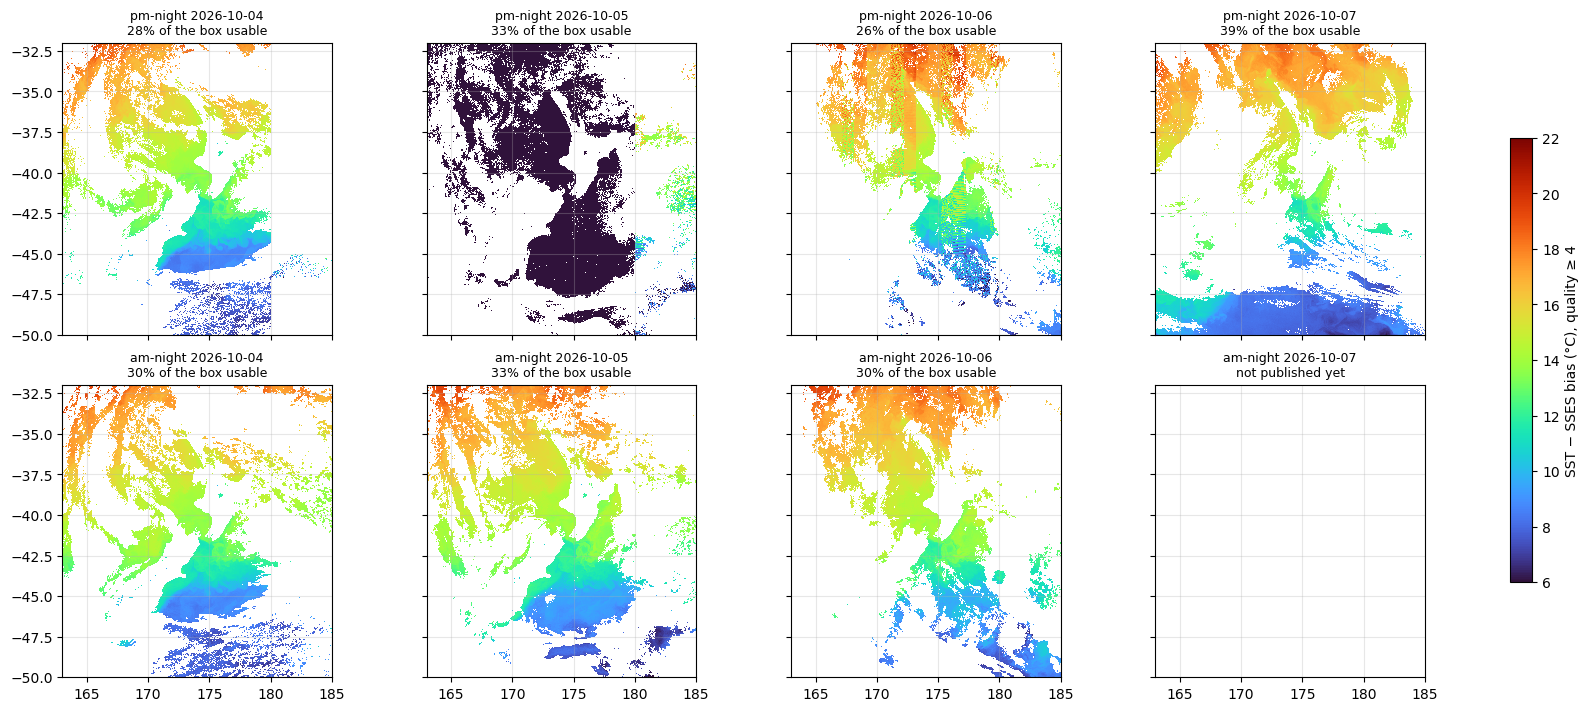

In [29]:
def good_sst(ds, min_quality=4):
    """Bias-corrected SST in °C where quality_level >= min_quality, else NaN."""
    sst = ds.sea_surface_temperature - ds.sses_bias - 273.15
    return sst.where(ds.quality_level >= min_quality)

# The products don't always have the same days: the newest granule of one can be
# published before the other's, so lay the panels out on the days either one has
days = sorted(set(np.concatenate([ds.time.values for ds in acspo.values()])))
fig, axes = plt.subplots(len(acspo), len(days), figsize=(4 * len(days), 7), sharex=True, sharey=True,
                         constrained_layout=True, squeeze=False)
for row, (key, ds) in enumerate(acspo.items()):
    sst = good_sst(ds)
    for col, day in enumerate(days):
        ax = axes[row, col]
        ax.set_aspect(1 / np.cos(np.deg2rad(41)))
        if day not in ds.time.values:
            ax.set_title(f"{key} {str(day)[:10]}\nnot published yet", fontsize=9)
            continue
        field = sst.sel(time=day)
        im = ax.pcolormesh(ds.lon, ds.lat, field, vmin=6, vmax=22, cmap="turbo", shading="auto")
        cover = 100 * float(field.notnull().mean())
        ax.set_title(f"{key} {str(day)[:10]}\n{cover:.0f}% of the box usable", fontsize=9)
fig.colorbar(im, ax=axes, shrink=0.7, label="SST − SSES bias (°C), quality ≥ 4")
plt.show()

### 4.2 Reference analysis: OSTIA (Met Office L4)

OSTIA is a gap-free daily analysis at 0.05°, built from many satellites and in-situ data. It isn't an observation to assimilate alongside ACSPO, since it already contains them. It is useful as a background, for quality checks, and for model initialisation and validation.

Here we compare it with one night of ACSPO, interpolating OSTIA onto the ACSPO pixels.

[OSTIA: 51 s]
ACSPO PM night minus OSTIA on 2026-10-06: mean +0.17 °C, std 0.86 °C, 259256 pixels


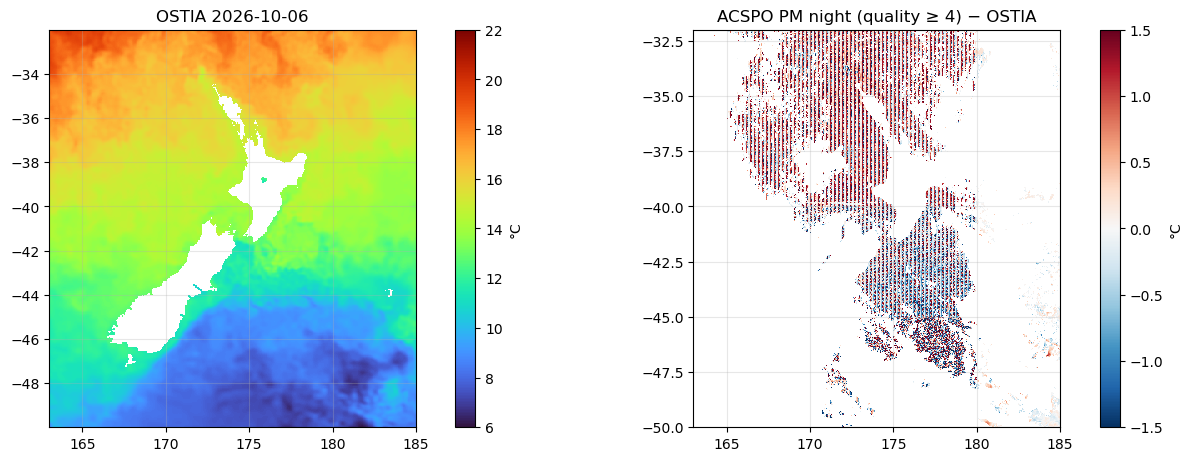

In [30]:
with timer("OSTIA"):
    ostia = query_domain("metoffice-glo-sst-l4-nrt-obs-sst-v2", variables=["analysed_sst"],
                         timefilter=timerange(ASSIM_WINDOW))
ostia_sst = ostia.analysed_sst - 273.15

day = ostia.time.values[-1]                     # the newest OSTIA day in the window
obs = good_sst(acspo["pm-night"]).sel(time=day, method="nearest")
ref = ostia_sst.sel(time=day).interp(longitude=obs.lon, latitude=obs.lat)
diff = obs - ref
print(f"ACSPO PM night minus OSTIA on {str(day)[:10]}: "
      f"mean {float(diff.mean()):+.2f} °C, std {float(diff.std()):.2f} °C, {int(diff.notnull().sum())} pixels")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
im = a.pcolormesh(ostia.longitude, ostia.latitude, ostia_sst.sel(time=day), vmin=6, vmax=22, cmap="turbo")
fig.colorbar(im, ax=a, label="°C"); a.set_title(f"OSTIA {str(day)[:10]}")
im = b.pcolormesh(diff.lon, diff.lat, diff, vmin=-1.5, vmax=1.5, cmap="RdBu_r")
fig.colorbar(im, ax=b, label="°C"); b.set_title("ACSPO PM night (quality ≥ 4) − OSTIA")
for ax in (a, b):
    ax.set_aspect(1 / np.cos(np.deg2rad(41)))
plt.show()

### 4.3 Argo profiles

`argo_floats` is the global Argo dataset, read live from Ifremer's ERDDAP server. It comes back as **one row per measurement**, in an `xarray.Dataset` with an `index` dimension, and `.to_dataframe()` makes it a pandas table. A profile is identified by `platform_number` + `cycle_number`.

Some points matter for assimilation:
- **Prefer the `*_adjusted` variables where they are filled.** These are delayed-mode corrected values. `data_mode` tells you which: `R` = real time, `A` = adjusted, `D` = delayed mode.
- **Keep the QC flags with the values.** They are `temp_qc`, `psal_qc` and `pres_qc`, plus `position_qc`, and 1 = good.
- **Pressure is in dbar, not metres.**

In [ ]:
with timer("Argo"):
    argo = query_domain("argo_floats",
                        variables=["platform_number", "cycle_number", "data_mode", "pres", "temp", "psal",
                                   "pres_qc", "temp_qc", "psal_qc", "position_qc"],
                        timefilter=timerange(ASSIM_WINDOW))
argo_df = argo.to_dataframe()
qc = [c for c in argo_df if c.endswith("_qc")]                 # ERDDAP serves QC flags as text
argo_df[qc] = argo_df[qc].apply(pd.to_numeric, errors="coerce")
good = argo_df[(argo_df.temp_qc == 1) & (argo_df.psal_qc == 1) & (argo_df.position_qc == 1)]
profiles = good.groupby(["platform_number", "cycle_number"])
print(f"{len(argo_df)} measurements, {profiles.ngroups} good profiles from {good.platform_number.nunique()} floats")
argo_df.head()

[Argo: 5 s]
8804 measurements, 10 good profiles from 10 floats


,cycle_number,data_mode,platform_number,position_qc,pres,pres_qc,psal,psal_qc,temp,temp_qc,latitude,longitude,time
index,,,,,,,,,,,,,
0,55.0,R,1902634,1,1.04,1,35.617599,1,17.377001,1,-33.28894,175.8817,2026-10-03 16:45:51
1,55.0,R,1902634,1,2.04,1,35.617401,1,17.377001,1,-33.28894,175.8817,2026-10-03 16:45:51
2,55.0,R,1902634,1,3.08,1,35.616402,1,17.375000,1,-33.28894,175.8817,2026-10-03 16:45:51
3,55.0,R,1902634,1,4.08,1,35.616001,1,17.375000,1,-33.28894,175.8817,2026-10-03 16:45:51
4,55.0,R,1902634,1,4.96,1,35.616001,1,17.372000,1,-33.28894,175.8817,2026-10-03 16:45:51


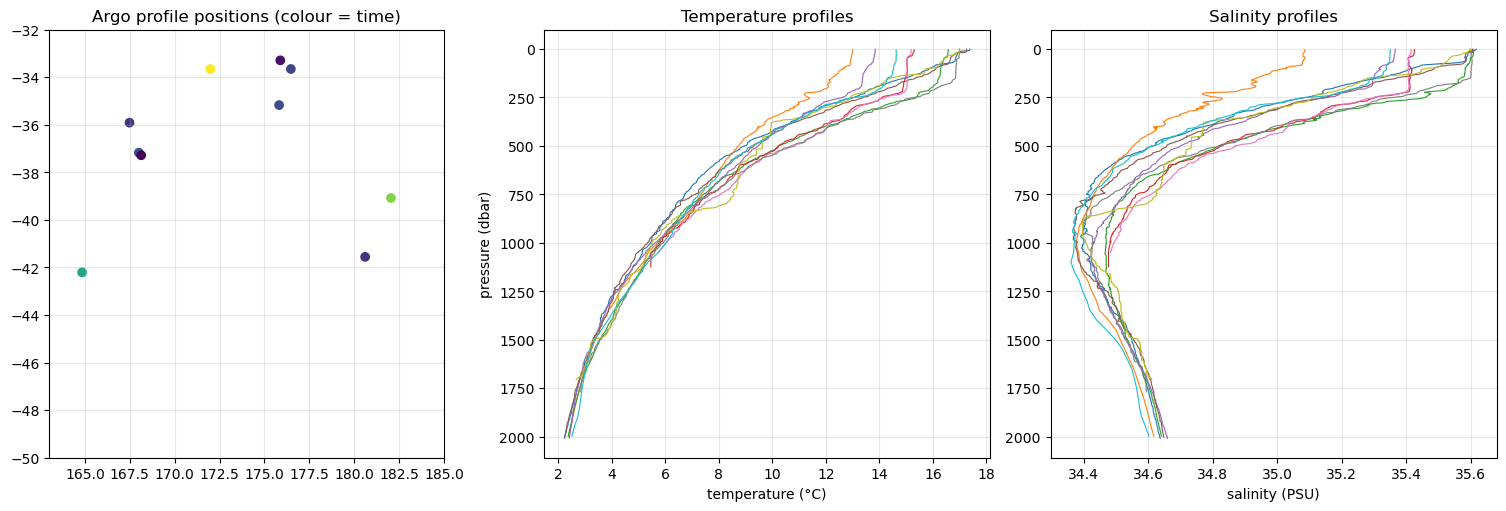

In [ ]:
fig, (a, b, c) = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
first = profiles.first()
sc = a.scatter(first.longitude, first.latitude, c=pd.to_datetime(first.time).astype("int64"), cmap="viridis")
a.set_xlim(DOMAIN[0], DOMAIN[2]); a.set_ylim(DOMAIN[1], DOMAIN[3])
a.set_aspect(1 / np.cos(np.deg2rad(41))); a.set_title("Argo profile positions (colour = time)")
for (_, profile) in profiles:
    b.plot(profile.temp, profile.pres, lw=0.8)
    c.plot(profile.psal, profile.pres, lw=0.8)
b.set(xlabel="temperature (°C)", ylabel="pressure (dbar)", title="Temperature profiles"); b.invert_yaxis()
c.set(xlabel="salinity (PSU)", title="Salinity profiles"); c.invert_yaxis()
plt.show()

### 4.4 Mangōpare sensors (Moana Project)

`moana-project-sensors` holds temperature from Mangōpare sensors on fishing gear, through EMODnet's ERDDAP. The data starts in October 2023. Each row is one measurement with `depth` (m) and `TEMP` (°C). `PLATFORMCODE` identifies a deployment, and the `*_QC` flags use 1 = good.

Gear profiles both on the way down and along the bottom, so there are many measurements per deployment.

[Mangōpare: 4 s]
60844 measurements, 43844 with good QC, 142 deployments


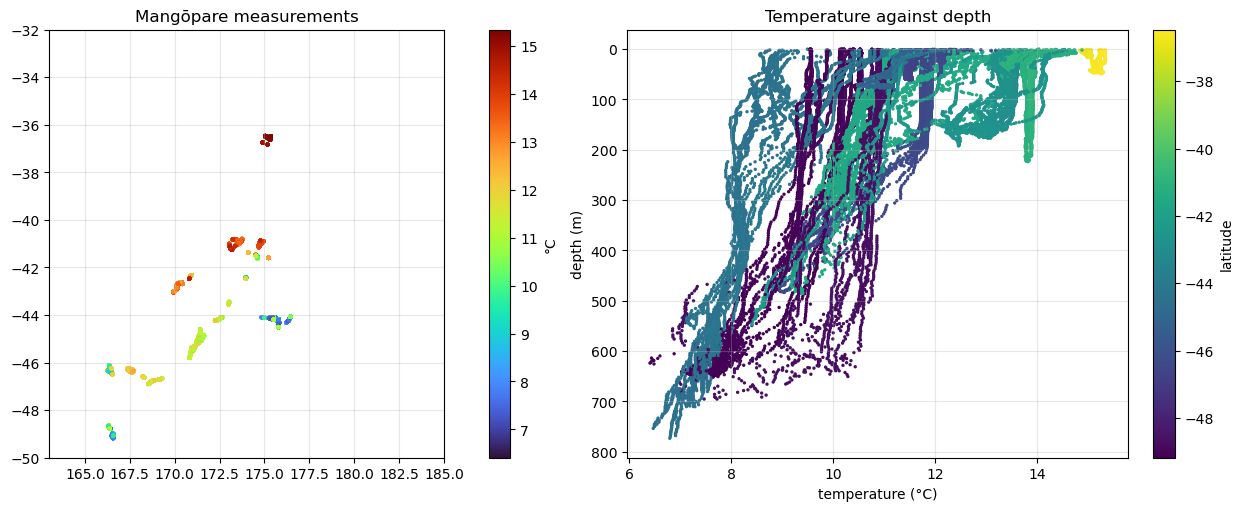

In [ ]:
with timer("Mangōpare"):
    mangopare = query_domain("moana-project-sensors", timefilter=timerange(ASSIM_WINDOW))
mdf = mangopare.to_dataframe()
mgood = mdf[(mdf.TEMP_QC == 1) & (mdf.DEPTH_QC == 1) & (mdf.POSITION_QC == 1)]
print(f"{len(mdf)} measurements, {len(mgood)} with good QC, {mgood.PLATFORMCODE.nunique()} deployments")

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sc = a.scatter(mgood.longitude, mgood.latitude, c=mgood.TEMP, s=4, cmap="turbo")
fig.colorbar(sc, ax=a, label="°C")
a.set_xlim(DOMAIN[0], DOMAIN[2]); a.set_ylim(DOMAIN[1], DOMAIN[3])
a.set_aspect(1 / np.cos(np.deg2rad(41))); a.set_title("Mangōpare measurements")
sc = b.scatter(mgood.TEMP, mgood.depth, c=mgood.latitude, s=2, cmap="viridis")
fig.colorbar(sc, ax=b, label="latitude"); b.invert_yaxis()
b.set(xlabel="temperature (°C)", ylabel="depth (m)", title="Temperature against depth")
plt.show()

## 5. Ocean initial and boundary conditions: Copernicus Marine GLO12

The Copernicus Marine global analysis and forecast (GLO12) is 1/12° with 50 levels. Each day it is extended about 10 days ahead, so it covers the whole forecast horizon. Datamesh reads it live from Copernicus Marine.

| id | contents |
|---|---|
| `cmems_mod_glo_phy-thetao_anfc_0-083deg_pt6h-i` | 3-D temperature, 6-hourly instantaneous |
| `cmems_mod_glo_phy-so_anfc_0-083deg_pt6h-i` | 3-D salinity, 6-hourly instantaneous |
| `cmems_mod_glo_phy_anfc_0-083deg_pt1h-m` | surface fields, hourly means: `zos` (sea surface height, **no tides**), `uo`/`vo`, `thetao`, `so` |

The first fetch of a 3-D field is still the slowest step in this notebook, at a few minutes. Datamesh then caches the result, so repeating the same query returns in seconds.

### 5.1 Initial conditions at T0

In [31]:
with timer("GLO12 3-D temperature at T0"):
    ic = query_domain("cmems_mod_glo_phy-thetao_anfc_0-083deg_pt6h-i",
                      timefilter={"type": "series", "times": [str(T0)]})   # 'series' = these exact times
ic

[GLO12 3-D temperature at T0: 131 s]


<xarray.Dataset> Size: 12MB
Dimensions:    (time: 1, elevation: 50, latitude: 217, longitude: 265)
Coordinates:
  * elevation  (elevation) float32 200B -5.728e+03 -5.275e+03 ... -1.541 -0.494
  * latitude   (latitude) float32 868B -50.0 -49.92 -49.83 ... -32.08 -32.0
  * time       (time) datetime64[ns] 8B 2026-10-07T12:00:00
  * longitude  (longitude) float32 1kB 163.0 163.1 163.2 ... 184.8 184.9 185.0
Data variables:
    thetao     (time, elevation, latitude, longitude) float32 12MB nan ... 16.99
Attributes: (12/16)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Information...
    institution:                   Mercator Ocean
    licence:                       http://marine.copernicus.eu/services-portf...
    ...                            ...
    references:                    http://marine.copernicus.eu
    source:                        MERCATOR GLO12
    title:                         Instantaneous fields for product GLOBAL_AN...
    _coordinates:                  {"t":"time","x":"longitude","y":"latitude"...
    _datamesh_cache_hash:          a1053bca62dc7adb4e4f9d3538ac7f04583d0b7a2d...
    _request_size:                 8855492

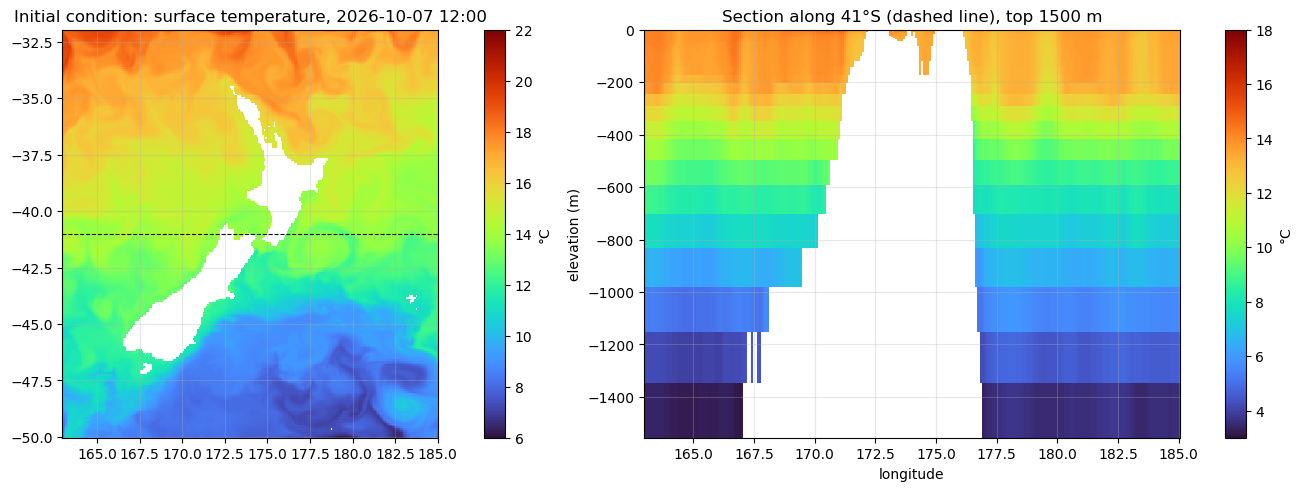

In [32]:
temp0 = ic.thetao.isel(time=0)
fig, (a, b) = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
surface = temp0.sel(elevation=temp0.elevation.max())
im = a.pcolormesh(ic.longitude, ic.latitude, surface, cmap="turbo", vmin=6, vmax=22)
fig.colorbar(im, ax=a, label="°C"); a.set_aspect(1 / np.cos(np.deg2rad(41)))
a.axhline(-41, color="k", lw=0.8, ls="--")
a.set_title(f"Initial condition: surface temperature, {str(T0)[:16]}")
section = temp0.sel(latitude=-41, method="nearest").where(lambda t: t.elevation > -1500, drop=True)
im = b.pcolormesh(section.longitude, section.elevation, section, cmap="turbo", vmin=3, vmax=18)
fig.colorbar(im, ax=b, label="°C"); b.set(xlabel="longitude", ylabel="elevation (m)",
                                         title="Section along 41°S (dashed line), top 1500 m")
plt.show()

### 5.2 Open boundary over the forecast horizon

Here is the northern boundary (32°S), as a thin strip, over the full 7 days. The other three boundaries work the same way. Notice that `query` needs **no `geofilter` change for depth**: the full water column comes back, and `levelfilter` would restrict it.

In [34]:
NORTH_BOUNDARY = [DOMAIN[0], DOMAIN[3] - 0.1, DOMAIN[2], DOMAIN[3] + 0.1]
with timer("GLO12 3-D temperature, northern boundary, 7 days"):
    obc = query_domain("cmems_mod_glo_phy-thetao_anfc_0-083deg_pt6h-i",
                       domain=NORTH_BOUNDARY, timefilter=timerange(FORECAST))
with timer("GLO12 surface hourly fields, northern boundary, 7 days"):
    obc_sfc = query_domain("cmems_mod_glo_phy_anfc_0-083deg_pt1h-m", domain=NORTH_BOUNDARY,
                           variables=["zos", "uo", "vo"], timefilter=timerange(FORECAST))
print(dict(obc.sizes), dict(obc_sfc.sizes))

[GLO12 surface hourly fields, northern boundary, 7 days: 52 s]
{'time': 29, 'elevation': 50, 'latitude': 3, 'longitude': 265} {'time': 169, 'elevation': 1, 'latitude': 3, 'longitude': 265}


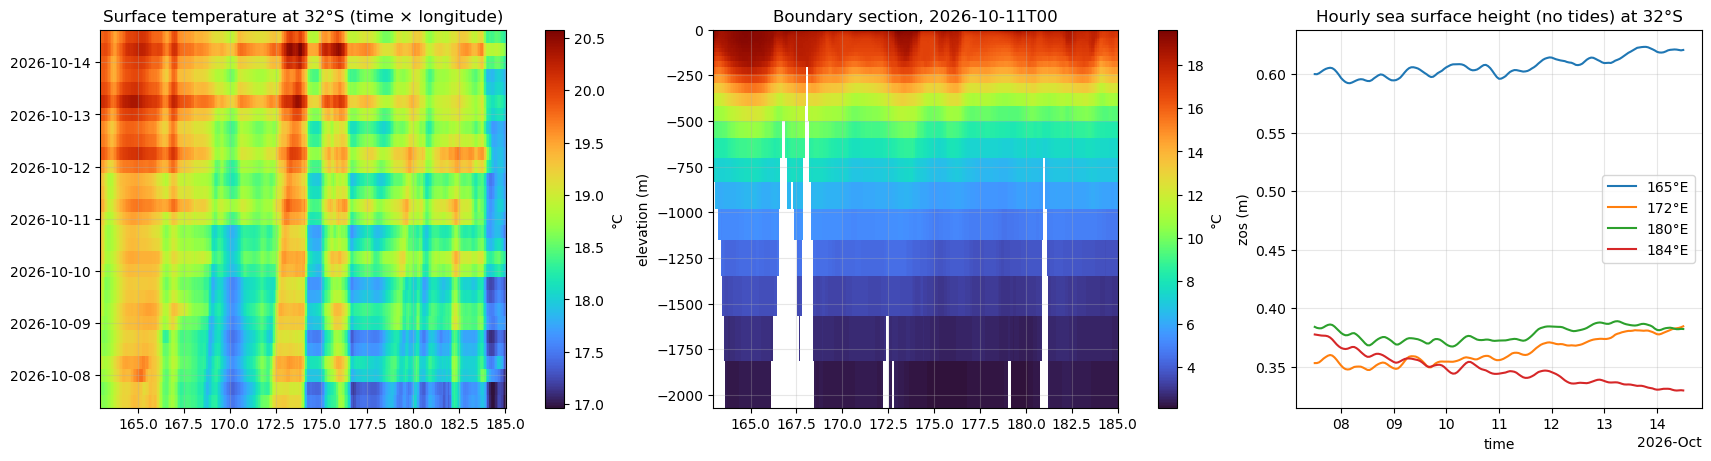

In [35]:
edge = obc.thetao.sel(latitude=DOMAIN[3], method="nearest")
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
im = axes[0].pcolormesh(edge.longitude, edge.time, edge.sel(elevation=edge.elevation.max()), cmap="turbo")
fig.colorbar(im, ax=axes[0], label="°C"); axes[0].set_title("Surface temperature at 32°S (time × longitude)")
mid = edge.isel(time=edge.sizes["time"] // 2).where(lambda t: t.elevation > -2000, drop=True)
im = axes[1].pcolormesh(mid.longitude, mid.elevation, mid, cmap="turbo")
fig.colorbar(im, ax=axes[1], label="°C")
axes[1].set(title=f"Boundary section, {str(mid.time.values)[:13]}", ylabel="elevation (m)")
ssh = obc_sfc.zos.sel(latitude=DOMAIN[3], method="nearest").squeeze()
for lon in [165, 172, 180, 184]:
    ssh.sel(longitude=lon, method="nearest").plot(ax=axes[2], label=f"{lon}°E")
axes[2].legend(); axes[2].set(title="Hourly sea surface height (no tides) at 32°S", ylabel="zos (m)")
plt.show()

## 6. Atmospheric forcing: ECMWF IFS 0.25°

`ecmwf_ifs_0p25_oper_sfc` serves ECMWF's IFS deterministic forecast from ECMWF's open-data bucket. It has 33 single-level fields, including everything bulk formulae need:
- 10 m wind (`u10`, `v10`);
- `t2m`, plus `d2m` (dewpoint, for humidity);
- `msl` and `sp`;
- downward short- and long-wave radiation (`ssrd`, `strd`);
- `tcc`;
- precipitation `tp`.

**Forecast cycles.** ECMWF runs at 00, 06, 12 and 18 UTC, and the datasource always serves **one cycle**.
- **By default you get the latest complete one.**
- **Choose a cycle with `parameters={"cycle": ...}`.** The datasource's metadata (`tstart`) tells you how far back the archive goes.
- **Use a 00 or 12 UTC cycle for a 7-day forecast.** The 00 and 12 UTC runs reach 15 days; the 06 and 18 UTC runs stop at 6 days.

**Time steps.** Steps are 3-hourly to 144 h, then 6-hourly.

**Accumulated fields are mean rates.** For example, `ssrd` is in W m⁻² and `tp` in m s⁻¹, averaged over the interval *ending* at each time step. They are not totals since the start of the run, so they can go straight into flux calculations.

**Resolution.** At 0.25° this is coarse for coastal New Zealand. A regional atmospheric model would add detail; ECMWF is the baseline available today.

In [36]:
with timer("ECMWF, 9 fields, 7 days"):
    met = query_domain("ecmwf_ifs_0p25_oper_sfc", parameters={"cycle": T0.isoformat()},
                       variables=["u10", "v10", "t2m", "d2m", "msl", "ssrd", "strd", "tcc", "tp"],
                       timefilter=timerange(FORECAST))
print("forecast cycle:", met.attrs.get("forecast_reference_time"))
met

[ECMWF, 9 fields, 7 days: 30 s]
forecast cycle: 2026-10-07T12:00:00Z


<xarray.Dataset> Size: 12MB
Dimensions:    (time: 53, latitude: 73, longitude: 89)
Coordinates:
  * latitude   (latitude) float32 292B -50.0 -49.75 -49.5 ... -32.5 -32.25 -32.0
  * time       (time) datetime64[ns] 424B 2026-10-07T12:00:00 ... 2026-10-14T...
  * longitude  (longitude) float32 356B 163.0 163.2 163.5 ... 184.5 184.8 185.0
Data variables:
    d2m        (time, latitude, longitude) float32 1MB 273.0 273.3 ... 288.2
    msl        (time, latitude, longitude) float32 1MB 1.03e+05 ... 1.024e+05
    ssrd       (time, latitude, longitude) float32 1MB nan nan nan ... 0.0 0.0
    strd       (time, latitude, longitude) float32 1MB nan nan ... 340.5 332.8
    t2m        (time, latitude, longitude) float32 1MB 280.3 280.4 ... 290.8
    tcc        (time, latitude, longitude) float32 1MB 0.2344 0.2266 ... 0.2734
    tp         (time, latitude, longitude) float32 1MB nan nan nan ... 0.0 0.0
    u10        (time, latitude, longitude) float32 1MB 2.646 2.724 ... 2.345
    v10        (time, latitude, longitude) float32 1MB 0.5099 0.713 ... -3.963
Attributes:
    Conventions:              CF-1.7
    _coordinates:             {"t":"time","x":"longitude","y":"latitude"}
    _datamesh_cache_hash:     5f3e9c436863500d682fc6ae1eaf95990d190eb21fc3451...
    _request_size:            12397348
    forecast_reference_time:  2026-10-07T12:00:00Z
    institution:              European Centre for Medium-Range Weather Foreca...
    license:                  CC-BY-4.0
    source:                   ECMWF open data (gs://ecmwf-open-data), ifs/0p2...
    title:                    ECMWF IFS open-data forecast, 0.25 deg, single-...

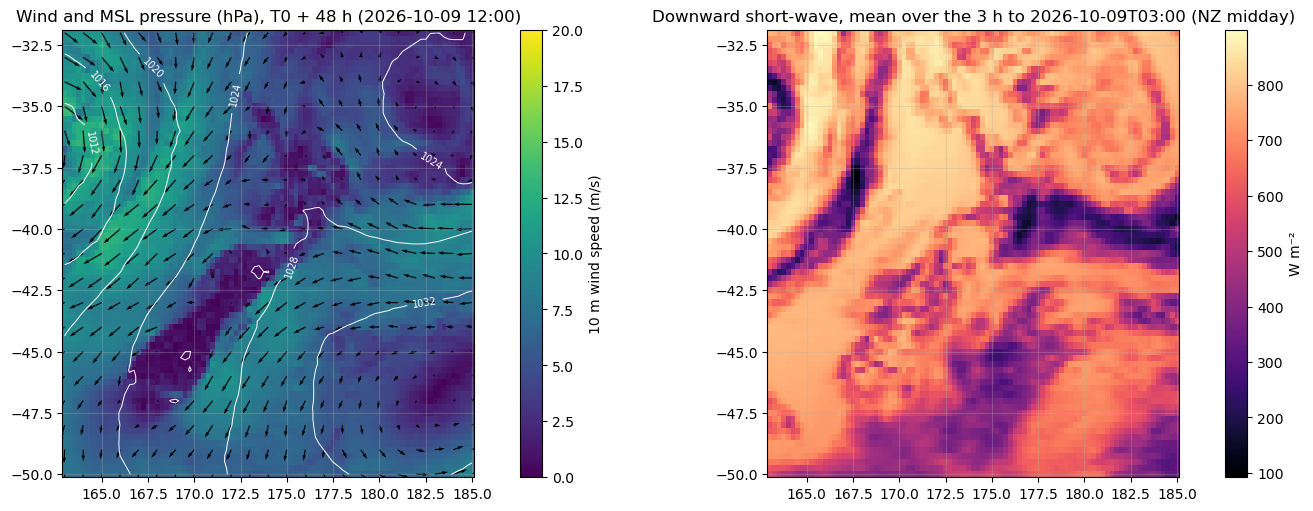

In [37]:
when = T0 + pd.Timedelta("48h")
snap = met.sel(time=when)
fig, (a, b) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
speed = np.hypot(snap.u10, snap.v10)
im = a.pcolormesh(met.longitude, met.latitude, speed, cmap="viridis", vmin=0, vmax=20)
fig.colorbar(im, ax=a, label="10 m wind speed (m/s)")
cs = a.contour(met.longitude, met.latitude, snap.msl / 100, levels=np.arange(960, 1050, 4), colors="w", linewidths=0.7)
a.clabel(cs, fontsize=7)
step = 4
a.quiver(met.longitude[::step], met.latitude[::step], snap.u10[::step, ::step], snap.v10[::step, ::step], color="k")
a.set_aspect(1 / np.cos(np.deg2rad(41))); a.set_title(f"Wind and MSL pressure (hPa), T0 + 48 h ({when:%Y-%m-%d %H:%M})")
noon = met.time.where(met.time.dt.hour == 3, drop=True).values[1]   # 00-03 UTC = NZ midday
im = b.pcolormesh(met.longitude, met.latitude, met.ssrd.sel(time=noon), cmap="magma")
fig.colorbar(im, ax=b, label="W m⁻²"); b.set_aspect(1 / np.cos(np.deg2rad(41)))
b.set_title(f"Downward short-wave, mean over the 3 h to {str(noon)[:16]} (NZ midday)")
plt.show()

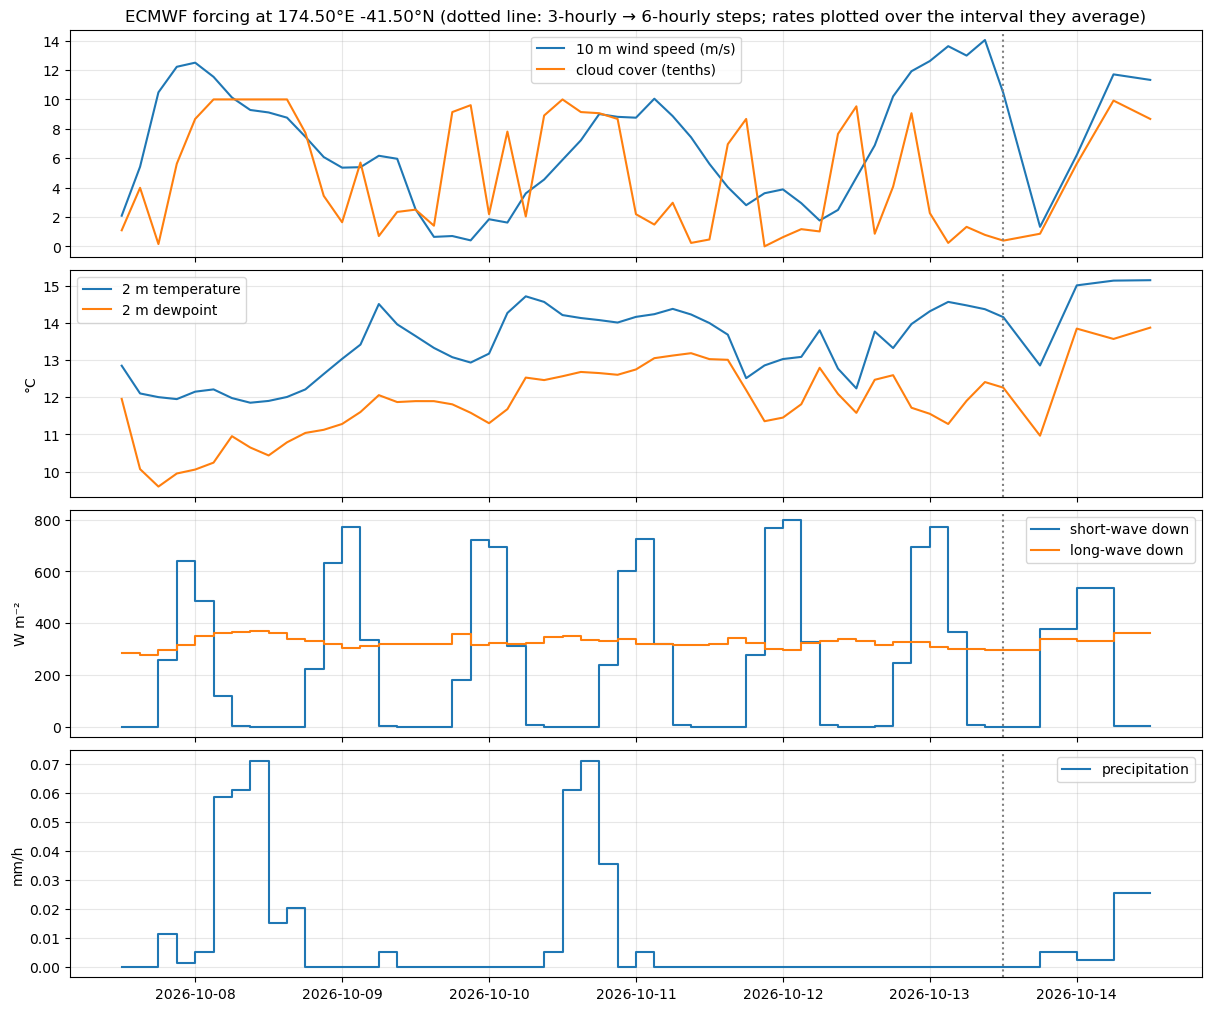

In [38]:
# Every bulk-flux input at one point in Cook Strait, over the whole forecast
point = met.sel(longitude=174.5, latitude=-41.5, method="nearest")
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, constrained_layout=True)
axes[0].plot(point.time, np.hypot(point.u10, point.v10), label="10 m wind speed (m/s)")
axes[0].plot(point.time, point.tcc * 10, label="cloud cover (tenths)"); axes[0].legend()
axes[1].plot(point.time, point.t2m - 273.15, label="2 m temperature")
axes[1].plot(point.time, point.d2m - 273.15, label="2 m dewpoint"); axes[1].set_ylabel("°C"); axes[1].legend()
axes[2].step(point.time, point.ssrd, where="pre", label="short-wave down")
axes[2].step(point.time, point.strd, where="pre", label="long-wave down"); axes[2].set_ylabel("W m⁻²"); axes[2].legend()
axes[3].step(point.time, point.tp * 3600 * 1000, where="pre", label="precipitation")
axes[3].set_ylabel("mm/h"); axes[3].legend()
for ax in axes:
    ax.axvline(T0 + pd.Timedelta("144h"), color="grey", ls=":")
axes[0].set_title(f"ECMWF forcing at {float(point.longitude):.2f}°E {float(point.latitude):.2f}°N "
                  "(dotted line: 3-hourly → 6-hourly steps; rates plotted over the interval they average)")
plt.show()

## 7. Tides: TPXO9

`tpxo9_v5a_cons` holds the TPXO9 v5a global tidal constituents on a 1/6° grid. It is static, with no time dimension:
- elevation (`h`) and transport velocities (`u`, `v`) as complex amplitudes, for 22 constituents along `con`;
- `dep`, the TPXO bathymetry.

Complex values come back split into real and imaginary parts, e.g. `h_re` and `h_im`.

Ocean models usually take these constituents directly, as tidal boundary forcing. The GLO12 sea surface height above contains no tides.

[TPXO9: 5 s]
constituents: [np.str_('M2'), np.str_('S2'), np.str_('N2'), np.str_('K2'), np.str_('K1'), np.str_('O1'), np.str_('P1'), np.str_('Q1'), np.str_('MM'), np.str_('MF'), np.str_('M4'), np.str_('MN4'), np.str_('MS4'), np.str_('2N2'), np.str_('S1'), np.str_('2Q1'), np.str_('J1'), np.str_('L2'), np.str_('M3'), np.str_('MU2'), np.str_('NU2'), np.str_('OO1')]


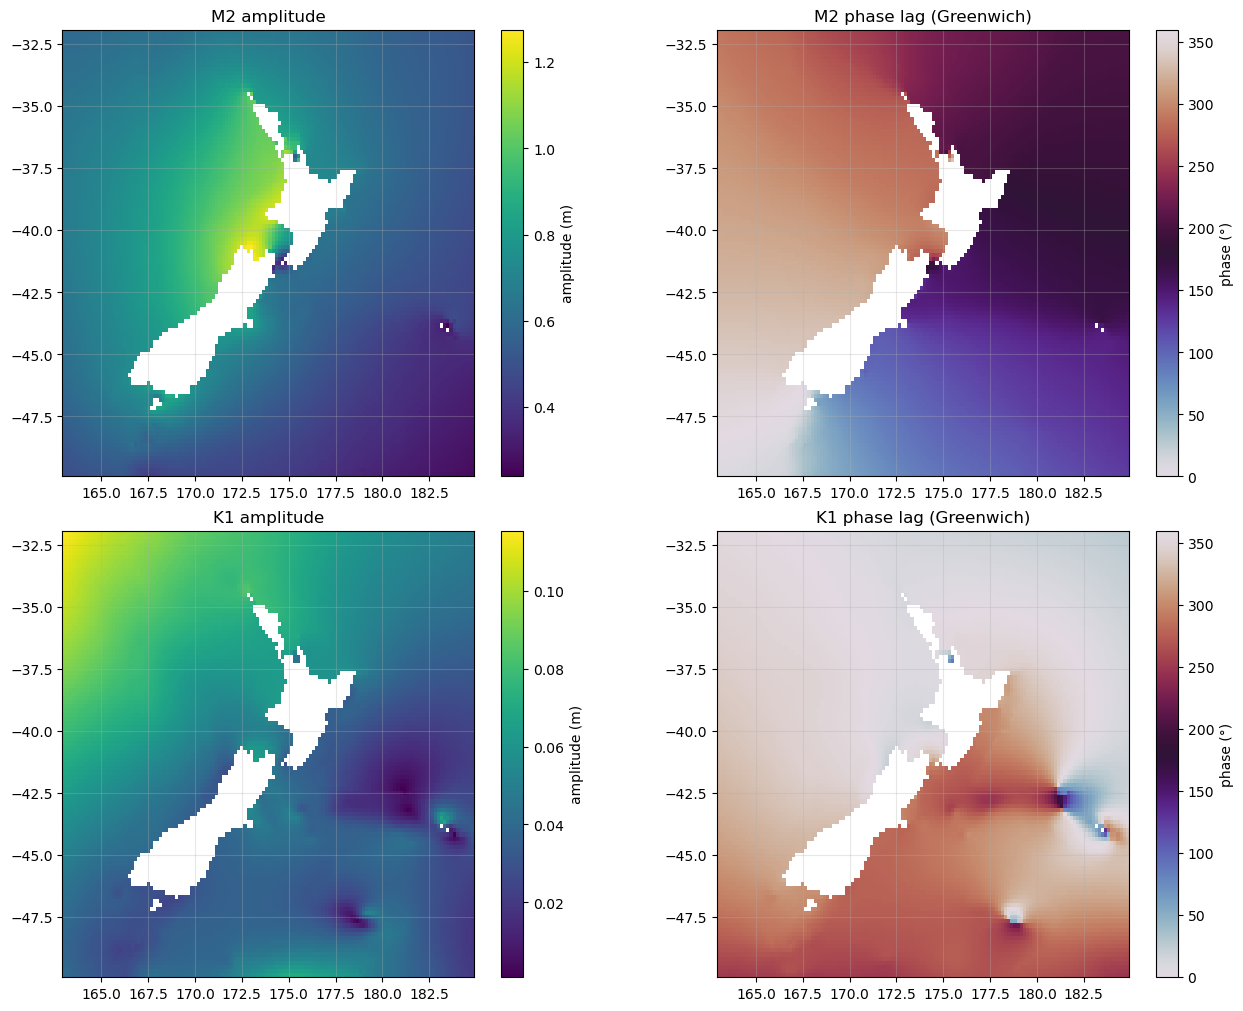

In [39]:
with timer("TPXO9"):
    tides = query_domain("tpxo9_v5a_cons", variables=["h"])
print("constituents:", list(tides.con.values))

h = tides.h_re + 1j * tides.h_im
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)
for row, name in zip(axes, ["M2", "K1"]):
    hc = h.sel(con=name)
    im = row[0].pcolormesh(tides.lon, tides.lat, np.abs(hc), cmap="viridis")
    fig.colorbar(im, ax=row[0], label="amplitude (m)"); row[0].set_title(f"{name} amplitude")
    phase = np.degrees(np.arctan2(-hc.imag, hc.real)) % 360   # TPXO convention: G = atan2(-h_im, h_re)
    im = row[1].pcolormesh(tides.lon, tides.lat, phase, cmap="twilight", vmin=0, vmax=360)
    fig.colorbar(im, ax=row[1], label="phase (°)"); row[1].set_title(f"{name} phase lag (Greenwich)")
    for ax in row:
        ax.set_aspect(1 / np.cos(np.deg2rad(41)))
plt.show()

## 8. Summary, gaps and tips

### What this run used

| Role | Datasource | Window | Resolution |
|---|---|---|---|
| SST observations | `noaa-acspo-l3s-leo-{am,pm}-{night,day}-podaac` | T0 − 3 d → T0 | 0.02°, daily per overpass |
| SST reference / background | `metoffice-glo-sst-l4-nrt-obs-sst-v2` | T0 − 3 d → T0 | 0.05°, daily |
| T/S profiles | `argo_floats` | T0 − 3 d → T0 | profiles |
| Temperature from fishing gear | `moana-project-sensors` | T0 − 3 d → T0 | measurements |
| Initial conditions | `cmems_mod_glo_phy-{thetao,so}_anfc_0-083deg_pt6h-i` | T0 | 1/12°, 50 levels |
| Open boundaries | `cmems_mod_glo_phy-{thetao,so}_anfc_0-083deg_pt6h-i`, `cmems_mod_glo_phy_anfc_0-083deg_pt1h-m` | T0 → T0 + 7 d | 1/12°, 6-hourly (3-D) / hourly (surface) |
| Atmosphere | `ecmwf_ifs_0p25_oper_sfc` | T0 → T0 + 7 d | 0.25°, 3-hourly then 6-hourly |
| Tides | `tpxo9_v5a_cons` | static | 1/6° |

### Not in Datamesh yet

**Rivers.** GloFAS is not yet available in Datamesh.

### Tips

- **Exploring vs fetching.** To explore, use `load_datasource` (lazy) and slice it in `xarray`. For a defined subset, use `query`; it does the subsetting on the server. To pass a query around or save it, build it as a `oceanum.datamesh.Query` object.
- **Caching.** Repeating a query is fast. A query is cached by its exact filters, so a fixed `T0` in a hindcast loop benefits more than a moving "latest".
- **Empty results.** A query that matches nothing returns `None` with a warning rather than raising. Check for it, especially for in-situ data in a short window.
- **Dates relative to now.** A `timefilter` also accepts periods relative to now, such as `["-P3D", "P7D"]` (3 days ago → 7 days ahead). That suits operational scripts, where a fixed `T0` suits reproducible runs.
- **Big requests.** Split by time (e.g. one day per query) rather than asking for weeks of 3-D fields at once. Also be gentle with the live providers: NASA, Copernicus and ERDDAP are shared public services, so don't run many queries in parallel.
- **Documentation:** https://oceanum-python.readthedocs.io/